In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

In [2]:
# Load the phenotype data
catalog_data = pd.read_csv('/work/pi_annagreen_umass_edu/mahbuba/resistance_forecast/data/derived_features/2021/expanded/2021_all_proteins_freq_proximity_aaindex_thermostability_llr.csv')


In [3]:
catalog_data.shape

(4677, 47)

In [4]:
catalog_data = catalog_data.drop_duplicates()

In [5]:
print(catalog_data.shape)

(4677, 47)


In [6]:
catalog_data['confidence'].value_counts()

confidence
3) Uncertain significance     4303
2) Assoc w R - Interim         160
1) Assoc w R                   155
5) Not assoc w R                38
4) Not assoc w R - Interim      21
Name: count, dtype: int64

In [7]:
catalog_data.columns

Index(['gene', 'fa_atr', 'fa_rep', 'fa_sol', 'fa_elec', 'fa_dun',
       'thermostability', 'Wildtype_AA', 'position', 'Mutated_AA',
       'one_letter_mutation', 'drug', 'confidence', 'delta_z', 'frequency',
       'phenotype', 'Proximity_to_R_Conferring', 'Nearest_Mutation_Index',
       'aa_index_dist', 'llr_score', 'mut_AAIndex1', 'mut_AAIndex2',
       'mut_AAIndex3', 'mut_AAIndex4', 'mut_AAIndex5', 'mut_AAIndex6',
       'mut_AAIndex7', 'mut_AAIndex8', 'delta_AAIndex1', 'delta_AAIndex2',
       'delta_AAIndex3', 'delta_AAIndex4', 'delta_AAIndex5', 'delta_AAIndex6',
       'delta_AAIndex7', 'delta_AAIndex8', 'llr_contributions',
       'expanded_llr_dim_553', 'expanded_llr_dim_279', 'expanded_llr_dim_291',
       'expanded_llr_dim_144', 'expanded_llr_dim_251', 'expanded_llr_dim_632',
       'expanded_llr_dim_98', 'expanded_llr_dim_532', 'expanded_llr_dim_382',
       'expanded_llr_dim_230'],
      dtype='object')

In [8]:
# Count the number of NaN rows in the 'Proximity_to_R_Conferring' column for each unique gene
nan_frequency_count = catalog_data.groupby('gene')['llr_score'].apply(lambda x: x.isna().sum())

# Display the result
print(nan_frequency_count)

gene
Rv0678    0
atpE      0
ddn       0
embB      0
ethA      0
fgd1      0
gid       0
gyrA      0
gyrB      0
inhA      0
katG      0
pepQ      0
pncA      0
rplC      0
rpoB      0
rpsL      0
tlyA      0
Name: llr_score, dtype: int64


In [9]:
# Filter out category 3 entries
label_data = catalog_data[catalog_data['confidence'] != "3) Uncertain significance"]

In [10]:
np.unique(label_data['confidence'].value_counts())

array([ 21,  38, 155, 160])

In [11]:

# List of numeric columns to use as features

# numeric_columns = ['frequency', 'Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability']
# numeric_columns = ['Proximity_to_R_Conferring', 'aa_index_dist','llr_score','thermostability']

numeric_columns = ['fa_atr', 'fa_rep', 'fa_sol', 'fa_elec', 'fa_dun','thermostability', 'Proximity_to_R_Conferring', 'llr_score', 'mut_AAIndex1', 'mut_AAIndex2',
       'mut_AAIndex3', 'mut_AAIndex4', 'mut_AAIndex5', 'mut_AAIndex6',
       'mut_AAIndex7', 'mut_AAIndex8', 'expanded_llr_dim_553', 'expanded_llr_dim_279', 'expanded_llr_dim_291',
       'expanded_llr_dim_144', 'expanded_llr_dim_251', 'expanded_llr_dim_632',
       'expanded_llr_dim_98', 'expanded_llr_dim_532', 'expanded_llr_dim_382',
       'expanded_llr_dim_230']

# Fill NaN values in the features with 0 or any suitable value
label_data[numeric_columns] = label_data[numeric_columns].fillna(0)

/tmp/ipykernel_3114205/3522647361.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_data[numeric_columns] = label_data[numeric_columns].fillna(0)


In [12]:
len(numeric_columns)

26

In [13]:
# Extract the feature matrix and target vector
X_label = label_data[numeric_columns]
y_label= label_data['confidence']

In [14]:
print(X_label.shape, y_label.shape)

(374, 26) (374,)


In [15]:
np.unique(y_label)

array(['1) Assoc w R', '2) Assoc w R - Interim',
       '4) Not assoc w R - Interim', '5) Not assoc w R'], dtype=object)

In [16]:
# Convert the target variable to numeric labels

y_label = y_label.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0, #replace 2 into 1 since the expected domain for gam is 0 or 1
    "5) Not assoc w R": 0
})

In [17]:
y_label.value_counts()

confidence
1    315
0     59
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

In [19]:
# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_label, test_size=0.3, random_state=42)

In [20]:
X_test_split.shape

(113, 26)

In [21]:
# import numpy as np
# from pygam import LogisticGAM
# # set seed
# RANDOM_SEED = 42
# np.random.seed(RANDOM_SEED)

# # Setting the parameters for random search
# N = 100  # Select 100 lambdas to search
# #lam_grid = np.random.uniform(1e-3, 1e3, size=(N, 16))  # Sampling in the linear range
# lam_grid = 10 ** np.random.uniform(-1, 2, size=(N, 16))#Sampling in the log range# work not bad  

# # Use gridsearch to search for the best lambda on these random candidates
# gam = LogisticGAM().gridsearch(X_train_split, y_train_split, lam=lam_grid)

# print("Optimized Lambda Values:", gam.lam)

 

In [22]:
# gam_clf = LogisticGAM(lam=gam.lam).fit(X_train_split, y_train_split)
# y_test_proba = gam_clf.predict_proba(X_test_split)

# custom_threshold = 0.5
# y_test_pred = (y_test_proba >= custom_threshold).astype(int)
# print("Predicted Classes:", y_test_pred[:10]) 
# accuracy = accuracy_score(y_test_split, y_test_pred)

In [23]:
# print(accuracy)

In [24]:
# cm = confusion_matrix(y_test_split, y_test_pred )
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.show()

In [25]:
#  # accuracy
# accuracy = accuracy_score(y_test_split, y_test_pred )
# print("\nAccuracy:", accuracy)

# # Classification
# print("\nClassification Report:")
# print(classification_report(y_test_split, y_test_pred )) 

In [26]:
#model with GAM
from pygam import LogisticGAM

# Directly train the GAM without lambda grid search(GCV instead)
gam = LogisticGAM().fit(X_train_split, y_train_split)
gam_clf = LogisticGAM().fit(X_train_split, y_train_split)
y_test_proba = gam_clf.predict_proba(X_test_split)

custom_threshold = 0.5
y_test_pred = (y_test_proba >= custom_threshold).astype(int)
print("Predicted Classes:", y_test_pred[:10]) 
accuracy = accuracy_score(y_test_split, y_test_pred)
print(accuracy)

AttributeError: 'csr_matrix' object has no attribute 'A'

In [ ]:
cm = confusion_matrix(y_test_split, y_test_pred )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [27]:
 # accuracy
accuracy = accuracy_score(y_test_split, y_test_pred )
print("\nAccuracy:", accuracy)

# Classification
print("\nClassification Report:")
print(classification_report(y_test_split, y_test_pred )) 


NameError: name 'y_test_pred' is not defined

y_prob_split.shape: (113, 2)
Unique classes: [0, 1]
Number of prediction columns in y_prob_split: 2
Class 0, AUC = 0.83
Class 1, AUC = 0.83


<function matplotlib.pyplot.show(close=None, block=None)>

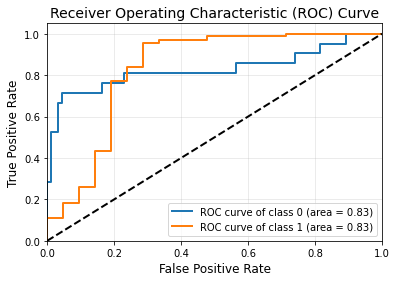

In [389]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Get the predicted probability
y_prob_split = gam_clf.predict_proba(X_test_split)

# 2. If it is a binary classification and only one column is returned, expand it to two columns [p(0), p(1)] = [1 - p, p]
if y_prob_split.ndim == 1:
    y_prob_split = np.column_stack([1 - y_prob_split, y_prob_split])
elif y_prob_split.shape[1] == 1:
    # If the shape is (n_samples,1), we can also squeeze it again
    y_prob_split = y_prob_split.squeeze(axis=1)
    y_prob_split = np.column_stack([1 - y_prob_split, y_prob_split])

print("y_prob_split.shape:", y_prob_split.shape)

# 3. Get the categories in the training set and sort them
unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])

# 4.Create a category -> column index mapping
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# 5. cauculate  ROC
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(f"Class {cls}, AUC = {roc_auc[cls]:.2f}")

# 6. plot
plt.figure()
for cls in unique_classes:
    plt.plot(fpr[cls], tpr[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})")
    
# Plot the diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)
# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show


In [289]:
# # Calculate AIC for the full model
# full_aic = gam.statistics_['AIC']

# # Calculate the change in AIC after removing each feature
# feature_importance = []
# for i in range(X_train_split.shape[1]):
#     X_modified = np.delete(X_train_split, i, axis=1)  # Remove the i-th feature
#     gam_temp = LogisticGAM().fit(X_modified, y_train_split)
#     reduced_aic = gam_temp.statistics_['AIC']
#     importance = full_aic - reduced_aic  # The greater the decrease in AIC, the more important the feature is.
#     feature_importance.append(importance)

# # result
# df_importance = pd.DataFrame({"Feature": range(X_train_split.shape[1]), 
#                               "Importance (AIC Reduction)": feature_importance})
# df_importance.sort_values(by="Importance (AIC Reduction)", ascending=False, inplace=True)

# # show table in table
# print(df_importance)


did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
    Feature  Importance (AIC Reduction)
2         2                    3.799770
13       13                    3.129871
15       15                    2.898083
8         8                    2.725975
1         1                    1.226306
11       11                    0.583651
9         9                    0.343548
10       10                   -0.214648
12       12                   -0.264802
5         5                   -0.879232
0         0                   -1.082623
3         3                   -1.348406
14       14                   -2.940707
7         7                   -7.654168
4         4                  -11.717440
6         6                  -39.760132


In [290]:
# import numpy as np
# import pandas as pd
# from pygam import LogisticGAM

# # train full LogisticGAM
# gam = LogisticGAM().fit(X_train_split, y_train_split)

# # get full models' AIC
# full_aic = gam.statistics_['AIC']

# # Calculate the change in AIC after removing each feature
# feature_importance = []
# for i in range(X_train_split.shape[1]):
#     X_modified = np.delete(X_train_split, i, axis=1)  
#     gam_temp = LogisticGAM().fit(X_modified, y_train_split)
#     reduced_aic = gam_temp.statistics_['AIC']
#     importance = full_aic - reduced_aic  # AIC Decline
#     feature_importance.append(importance)

# # result
# df_importance = pd.DataFrame({"Feature": range(X_train_split.shape[1]), 
#                               "Importance (AIC Reduction)": feature_importance})
# df_importance.sort_values(by="Importance (AIC Reduction)", ascending=False, inplace=True)

# # show result
# print(df_importance)


did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
    Feature  Importance (AIC Reduction)
2         2                    3.799770
13       13                    3.129871
15       15                    2.898083
8         8                    2.725975
1         1                    1.226306
11       11                    0.583651
9         9                    0.343548
10       10                   -0.214648
12       12                   -0.264802
5         5                   -0.879232
0         0                   -1.082623
3         3                   -1.348406
14       14                   -2.940707
7         7                   -7.654168
4         4                  -11.717440
6         6                  -39.760132


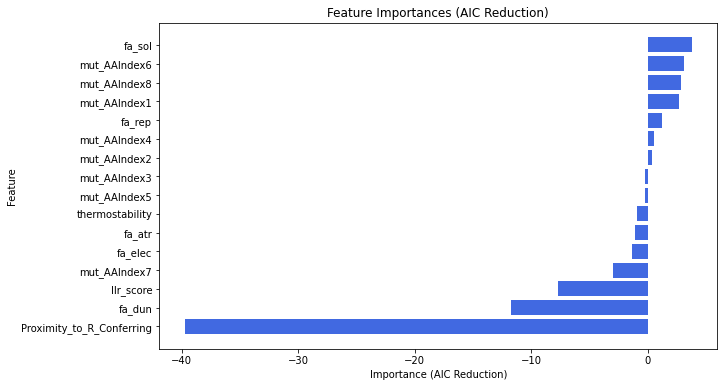

In [291]:
# feature_names_mapping = [
#     "fa_atr", "fa_rep", "fa_sol", "fa_elec", "fa_dun",
#     "thermostability", "Proximity_to_R_Conferring", "llr_score",
#     "mut_AAIndex1", "mut_AAIndex2", "mut_AAIndex3", "mut_AAIndex4",
#     "mut_AAIndex5", "mut_AAIndex6", "mut_AAIndex7", "mut_AAIndex8"
# ]

# # Name mapping based on the original Feature index
# df_importance["Feature Name"] = df_importance["Feature"].apply(lambda x: feature_names_mapping[x])

# # Sort by importance
# df_importance = df_importance.sort_values(by="Importance (AIC Reduction)", ascending=False)

# # plot
# plt.figure(figsize=(10, 6))
# plt.barh(df_importance["Feature Name"], df_importance["Importance (AIC Reduction)"], color="royalblue")
# plt.xlabel("Importance (AIC Reduction)")
# plt.ylabel("Feature")
# plt.title("Feature Importances (AIC Reduction)")
# plt.gca().invert_yaxis()  # Reverse the y-axis so that the most important items are on top
# plt.show()

In [390]:
gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     37.6003
Link Function:                        LogitLink Log Likelihood:                                   -38.5471
Number of Samples:                          261 AIC:                                              152.2948
                                                AICc:                                             166.1032
                                                UBRE:                                               2.6988
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6441
Feature Function                  Lam

/var/folders/pf/drpv705s1dl6nzs53qkr38300000gn/T/ipykernel_26528/3358381670.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


[7.173150962103136e-13, 0.858737274905062, 0.14399100518975017, 0.7918843249307793, 0.020170675761700507, 0.06133768576219423, 4.897896408184721e-05, 0.03332391846706273, 0.1881707881116378, 0.3355572680215675, 0.12119428017499345, 0.20031136658720738, 0.1939535113056119, 0.06802228382970099, 0.024909722835469328, 0.14607515520117942]
['fa_atr', 'fa_rep', 'fa_sol', 'fa_elec', 'fa_dun', 'thermostability', 'Proximity_to_R_Conferring', 'llr_score', 'mut_AAIndex1', 'mut_AAIndex2', 'mut_AAIndex3', 'mut_AAIndex4', 'mut_AAIndex5', 'mut_AAIndex6', 'mut_AAIndex7', 'mut_AAIndex8']


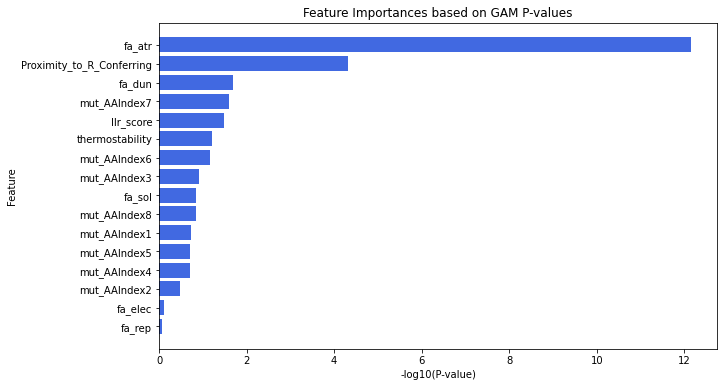

In [391]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# get p value
p_values = gam.statistics_['p_values']
p_values = p_values[:-1] # remove intercept
print(p_values)
print(feature_names)

# transform to dataFrame
df_importance = pd.DataFrame({"Feature": feature_names, "P-value": p_values})

# Sort by P-value (the smaller the P-value, the more important the feature)
df_importance = df_importance.sort_values(by="P-value", ascending=True)

# plot
plt.figure(figsize=(10, 6))
plt.barh(df_importance["Feature"], -np.log10(df_importance["P-value"]), color="royalblue")
plt.xlabel("-log10(P-value)")
plt.ylabel("Feature")
plt.title("Feature Importances based on GAM P-values")
plt.gca().invert_yaxis()  # Put the most important features at the top
plt.show()


In [29]:
#Multivariate Adaptive Regression Splines (MARS)
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

# activate transform between pandas and R  
pandas2ri.activate()

# import r package 
base = importr('base')
utils = importr('utils')
earth = importr('earth')


In [32]:
# try several degree for MARS
mars_model = earth.earth(X_train_split, y_train_split ,degree =4) #when degree=4 ..., it will have high acc
#when degree=1,2,3 acc=89%
#It is best not to have a high degree, as a high degree will lead to a lack of interpretability.

# use predict() function in R to predict
predict = ro.r['predict']  # loading predict() from R
y_pred_r = predict(mars_model, X_test_split, type = "class")  # prediction

# transform matrix(in R) to numpy 
y_test_pred = np.array(y_pred_r) 
 
# Calculate the accuracy
accuracy_score(y_test_split, y_test_pred)
print(accuracy_score(y_test_split, y_test_pred))

0.8849557522123894


In [33]:
summary = ro.r['summary']
model_summary = summary(mars_model)
print(model_summary)

Call: earth(x=matrix[261,26], y=c(1,1,0,1,1,1,1...), degree=4)

                                                                       coefficients
(Intercept)                                                              0.69172403
h(x1-1.15239)                                                            0.14124082
h(-1.29382-x5)                                                          -0.65531329
h(x7-0.900818)                                                          -1.80793485
h(1.25441-x7)                                                            0.18474679
h(x7-1.25441)                                                            1.77658594
h(x23-0.0269455)                                                         0.06360999
h(-1.29382-x5) * x14                                                    -1.83267008
h(x5- -1.29382) * h(-0.723523-x25)                                      -0.11085941
x2 * h(-1.29382-x5) * x14                                               -2.06443141
h(x5- -1.293

              precision    recall  f1-score   support

           0       0.75      0.57      0.65        21
           1       0.91      0.96      0.93        92

    accuracy                           0.88       113
   macro avg       0.83      0.76      0.79       113
weighted avg       0.88      0.88      0.88       113



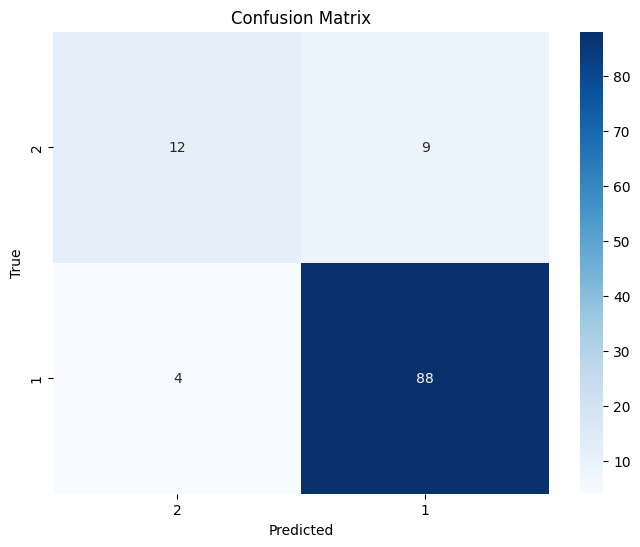

In [34]:
print(classification_report(y_test_split, y_test_pred))
cm = confusion_matrix(y_test_split, y_test_pred )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Unique classes: [0, 1]
Class 0 AUC: 0.76
Class 1 AUC: 0.76


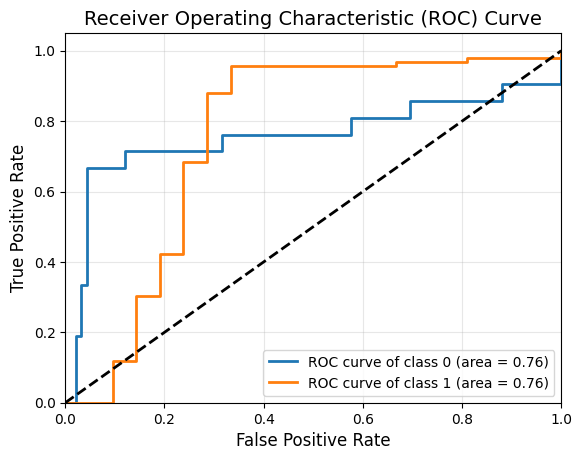

In [35]:
# use the predic function in R on the mars model
predict = ro.r['predict'] # use predict function in R
# use mars to predict
y_pred_response = np.array(predict(mars_model, X_test_split, type="response"))
 
y_prob_split = np.column_stack([1 - y_pred_response, y_pred_response])

# transform into numpy
y_pred_r = predict(mars_model, X_test_split, type="class")  
 

unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)

class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}
fpr = {}
tpr = {}
roc_auc = {}

# calculate roc and auc for each category  
for cls in unique_classes:
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(f"Class {cls} AUC: {roc_auc[cls]:.2f}")

# roc figure
plt.figure()

for cls in unique_classes:
    plt.plot(fpr[cls], tpr[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})")

 
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [36]:
# find the difference between 2023 and 2021
from IPython.display import display
import pandas as pd

# Load the 2021 and 2023 datasets
file_2021 = "/work/pi_annagreen_umass_edu/mahbuba/resistance_forecast/data/derived_features/2021/expanded/2021_all_proteins_freq_proximity_aaindex_thermostability_llr.csv"
file_2023 = "/work/pi_annagreen_umass_edu/mahbuba/resistance_forecast/data/derived_features/all_proteins_freq_details_proximity_aaindex_thermostability.csv"

df_2021 = pd.read_csv(file_2021)
df_2023 = pd.read_csv(file_2023)

In [37]:
# Merge the two datasets on gene, Wildtype_AA, position, Mutated_AA
merged_df = pd.merge(
    df_2021,
    df_2023,
    on=['gene', 'one_letter_mutation'],
    suffixes=('_2021', '_2023')
)
merged_df=merged_df.drop_duplicates()

In [38]:
# Filter rows where confidence remained unchanged in category 3
unchanged_category_3 = merged_df[
    (merged_df['confidence_2021'] == "3) Uncertain significance") &
    (merged_df['confidence_2023'] == "3) Uncertain significance")
]
unchanged_category_3 = unchanged_category_3.drop_duplicates()

# Count the number of positions where the confidence remained unchanged
num_unchanged = unchanged_category_3.shape[0]

print(f"Number of positions where confidence remained unchanged in category 3: {num_unchanged}")

# Optionally, preview the unchanged rows
display(unchanged_category_3[['gene', 'one_letter_mutation', 'confidence_2021', 'confidence_2023']])

Number of positions where confidence remained unchanged in category 3: 5164


,gene,one_letter_mutation,confidence_2021,confidence_2023
0,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
1,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
2,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
3,Rv0678,S2I,3) Uncertain significance,3) Uncertain significance
4,Rv0678,S2R,3) Uncertain significance,3) Uncertain significance
...,...,...,...,...
5693,tlyA,R244P,3) Uncertain significance,3) Uncertain significance
5694,tlyA,A250T,3) Uncertain significance,3) Uncertain significance
5695,tlyA,R249Q,3) Uncertain significance,3) Uncertain significance
5696,tlyA,S252L,3) Uncertain significance,3) Uncertain significance


In [39]:
# Exclude rows where confidence is "3) Uncertain significance" in both files
filtered_df = merged_df[
    ~((merged_df['confidence_2021'] == "3) Uncertain significance") &
      (merged_df['confidence_2023'] == "3) Uncertain significance"))
]

# Identify rows where confidence values differ between 2021 and 2023
updated_confidence = filtered_df[
    filtered_df['confidence_2021'] != filtered_df['confidence_2023']
]

In [40]:
print(merged_df.shape,filtered_df.shape,updated_confidence.shape)

(5698, 60) (534, 60) (169, 60)


In [41]:
filtered_df=filtered_df.drop_duplicates()

In [42]:
filtered_df['confidence_2021'].value_counts()

confidence_2021
1) Assoc w R                  170
2) Assoc w R - Interim        169
3) Uncertain significance     111
5) Not assoc w R               59
4) Not assoc w R - Interim     25
Name: count, dtype: int64

In [43]:
filtered_df['confidence_2023'].value_counts()

confidence_2023
2) Assoc w R - Interim        220
1) Assoc w R                  207
5) Not assoc w R               65
4) Not assoc w R - Interim     25
3) Uncertain significance      17
Name: count, dtype: int64

In [44]:
# Check for rows where confidence is 3 in both 2021 and 2023
confidence_3_in_both = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] == "3) Uncertain significance")
]

# Display the result
print(f"Number of rows with confidence 3 in both 2021 and 2023: {confidence_3_in_both.shape[0]}")
print(confidence_3_in_both)

Number of rows with confidence 3 in both 2021 and 2023: 0
Empty DataFrame
Columns: [gene, fa_atr, fa_rep, fa_sol, fa_elec, fa_dun, thermostability_2021, Wildtype_AA_2021, position_2021, Mutated_AA_2021, one_letter_mutation, drug_2021, confidence_2021, delta_z_2021, frequency_2021, phenotype_2021, Proximity_to_R_Conferring_2021, Nearest_Mutation_Index_2021, aa_index_dist_2021, llr_score_2021, mut_AAIndex1, mut_AAIndex2, mut_AAIndex3, mut_AAIndex4, mut_AAIndex5, mut_AAIndex6, mut_AAIndex7, mut_AAIndex8, delta_AAIndex1, delta_AAIndex2, delta_AAIndex3, delta_AAIndex4, delta_AAIndex5, delta_AAIndex6, delta_AAIndex7, delta_AAIndex8, llr_contributions, expanded_llr_dim_553, expanded_llr_dim_279, expanded_llr_dim_291, expanded_llr_dim_144, expanded_llr_dim_251, expanded_llr_dim_632, expanded_llr_dim_98, expanded_llr_dim_532, expanded_llr_dim_382, expanded_llr_dim_230, thermostability_2023, Wildtype_AA_2023, position_2023, Mutated_AA_2023, drug_2023, confidence_2023, delta_z_2023, frequency_202

In [45]:
# Filter for confidence_2021 == "3) Uncertain significance" that changed to other categories
confidence_3_changed = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] != "3) Uncertain significance")
]
confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence_2021','confidence_2023'])
# Count value occurrences in confidence_2023
changed_counts = confidence_3_changed['confidence_2023'].value_counts()

# Display the result
print(f"Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: {confidence_3_changed.shape[0]}")
print("Value counts of the changed categories in 2023:")
print(changed_counts)

Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: 81
Value counts of the changed categories in 2023:
confidence_2023
2) Assoc w R - Interim        55
1) Assoc w R                  15
5) Not assoc w R               6
4) Not assoc w R - Interim     5
Name: count, dtype: int64


In [49]:
confidence_3_changed

,gene,fa_atr,fa_rep,fa_sol,fa_elec,fa_dun,thermostability_2021,Wildtype_AA_2021,position_2021,Mutated_AA_2021,...,Mutated_AA_2023,drug_2023,confidence_2023,delta_z_2023,frequency_2023,phenotype_2023,Proximity_to_R_Conferring_2023,Nearest_Mutation_Index_2023,aa_index_dist_2023,llr_score_2023
57,Rv0678,5.215,-1.648000,7.674,-2.934,-0.590,4.401591,L,32,S,...,S,Bedaquiline,2) Assoc w R - Interim,0.147523,0.833333,Resistant,2.799001,36.0,37.326490,5.877594
61,Rv0678,-4.125,42.218000,1.446,1.016,0.785,42.607373,A,36,V,...,V,Bedaquiline,2) Assoc w R - Interim,0.107635,1.000000,Resistant,2.799001,32.0,27.720968,-5.190504
82,Rv0678,-14.350,48.784182,15.766,-1.145,5.769,49.007560,C,46,R,...,R,Clofazimine,2) Assoc w R - Interim,0.222652,1.000000,Resistant,7.195753,36.0,40.517919,4.639270
134,Rv0678,1.251,-0.946000,2.381,-1.239,0.355,0.549397,N,70,D,...,D,Bedaquiline,2) Assoc w R - Interim,0.122702,0.857143,Resistant,3.117993,67.0,20.632582,-3.783930
136,Rv0678,10.841,-4.767000,5.152,-0.575,-1.744,7.209093,I,67,S,...,S,Bedaquiline,2) Assoc w R - Interim,0.178202,1.000000,Resistant,3.117993,70.0,38.250585,8.924705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4970,pncA,2.386,2.502000,-0.346,0.028,2.233,7.673205,L,159,V,...,V,Pyrazinamide,2) Assoc w R - Interim,0.052354,0.600000,Resistant,1.330143,160.0,21.748474,4.245023
4972,pncA,4.577,0.060000,-3.106,2.080,-0.386,5.972033,T,160,A,...,A,Pyrazinamide,4) Not assoc w R - Interim,0.058988,0.571429,Susceptible,1.330143,159.0,26.416943,4.286821
4978,pncA,1.898,-0.142000,-0.296,0.115,0.025,0.657171,V,163,A,...,A,Pyrazinamide,2) Assoc w R - Interim,0.053480,0.750000,Resistant,1.326742,162.0,27.720968,2.453124
4991,pncA,2.792,45.971000,-1.253,-0.681,0.313,47.527063,M,175,I,...,I,Pyrazinamide,2) Assoc w R - Interim,0.069766,0.500000,Resistant,3.468004,177.0,24.487350,0.459367


In [50]:
print(confidence_3_changed['confidence_2021'].unique())
print(confidence_3_changed['confidence_2023'].unique())

['3) Uncertain significance']
['2) Assoc w R - Interim' '1) Assoc w R' '5) Not assoc w R'
 '4) Not assoc w R - Interim']


In [51]:
# Convert the target var 
 

mapping = {
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0,
    "5) Not assoc w R": 0,
}

confidence_3_changed['confidence_2023'] = confidence_3_changed['confidence_2023'].map(mapping)

print(confidence_3_changed[['confidence_2021', 'confidence_2023']])
print(confidence_3_changed['confidence_2023'].unique())

                confidence_2021  confidence_2023
57    3) Uncertain significance                1
61    3) Uncertain significance                1
82    3) Uncertain significance                1
134   3) Uncertain significance                1
136   3) Uncertain significance                1
...                         ...              ...
4970  3) Uncertain significance                1
4972  3) Uncertain significance                0
4978  3) Uncertain significance                1
4991  3) Uncertain significance                1
4993  3) Uncertain significance                1

[81 rows x 2 columns]
[1 0]


In [52]:
# Step 0: Remove duplicates from both DataFrames
catalog_data = catalog_data.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence'])
# confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation'])

# Step 1: Select mutation positions from confidence_3_changed
selected_positions = confidence_3_changed[['gene', 'one_letter_mutation', 'confidence_2023']]

# Step 2: Filter category_3_data to match the selected positions
category_3_data = catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data = category_3_data.merge(selected_positions, on=['gene', 'one_letter_mutation'], how='inner')

# Check the shape
print(f"Shape of filtered category_3_data after dropping duplicates: {category_3_data.shape}")
# Step 1: Select mutation positions from confidence_3_changed (use one_letter_mutation_2021)
selected_positions = confidence_3_changed[['gene', 'one_letter_mutation', 'confidence_2023']]
# Step 2: Filter category_3_data to match the selected positions
category_3_data = catalog_data[catalog_data['confidence'] == "3) Uncertain significance"]
category_3_data = category_3_data.merge(selected_positions, on=['gene', 'one_letter_mutation'], how='inner')
# category_3_data = category_3_data.drop_duplicates()
category_3_data.shape

Shape of filtered category_3_data after dropping duplicates: (81, 48)


(81, 48)

In [53]:
# Step 3: Prepare data for prediction
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)  # Handle missing values
X_category_3 = category_3_data[numeric_columns]
print(X_category_3)

    fa_atr     fa_rep  fa_sol  fa_elec  fa_dun  thermostability  \
0    5.215  -1.648000   7.674   -2.934  -0.590         4.401591   
1   -4.125  42.218000   1.446    1.016   0.785        42.607373   
2  -14.350  48.784182  15.766   -1.145   5.769        49.007560   
3    1.251  -0.946000   2.381   -1.239   0.355         0.549397   
4   10.841  -4.767000   5.152   -0.575  -1.744         7.209093   
..     ...        ...     ...      ...     ...              ...   
76   2.386   2.502000  -0.346    0.028   2.233         7.673205   
77   4.577   0.060000  -3.106    2.080  -0.386         5.972033   
78   1.898  -0.142000  -0.296    0.115   0.025         0.657171   
79   2.792  45.971000  -1.253   -0.681   0.313        47.527063   
80  -3.226  41.332450   9.354   -0.898   5.179        43.934364   

    Proximity_to_R_Conferring  llr_score  mut_AAIndex1  mut_AAIndex2  ...  \
0                    0.000000   5.877598    -12.768331      7.992347  ...   
1                    0.000000  -5.190502 

In [54]:
y_test_proba = gam_clf.predict_proba(X_category_3)
custom_threshold = 0.5
y_test_pred = (y_test_proba >= custom_threshold).astype(int)
print(y_test_pred)

NameError: name 'gam_clf' is not defined

In [55]:
cm = confusion_matrix( category_3_data['confidence_2023'],y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [81, 113]

In [56]:
y_test_pred

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
    

In [57]:
 category_3_data['confidence_2023']

0     1
1     1
2     1
3     1
4     1
     ..
76    1
77    0
78    1
79    1
80    1
Name: confidence_2023, Length: 81, dtype: int64

In [58]:
print(classification_report(category_3_data['confidence_2023'],  y_test_pred))

ValueError: Found input variables with inconsistent numbers of samples: [81, 113]

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Get the predicted probability
y_test_proba = gam_clf.predict_proba(X_category_3)

# 2. If it is a binary classification and only one column is returned, expand it to two columns  [p(0), p(1)] = [1 - p, p]
if y_test_proba.ndim == 1:
    y_test_proba = np.column_stack([1 - y_test_proba, y_test_proba])
elif y_test_proba.shape[1] == 1: 
    y_test_proba = y_test_proba.squeeze(axis=1)
    y_test_proba = np.column_stack([1 - y_test_proba, y_test_proba])

print("y_test_proba.shape:", y_test_proba.shape)



NameError: name 'gam_clf' is not defined

In [60]:
# 3. Get the categories in the training set and sort them
unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_test_proba.shape[1])

# 4. Create a category -> column index mapping
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# 5. caculate ROC
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    idx = class_to_index[cls] 
    fpr[cls], tpr[cls], _ = roc_curve(category_3_data['confidence_2023'] == cls, y_test_proba[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(f"Class {cls}, AUC = {roc_auc[cls]:.2f}")

# 6. plot
plt.figure()
for cls in unique_classes:
    plt.plot(fpr[cls], tpr[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})")
    
# Plot the diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)
# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show

Unique classes: [0, 1]


NameError: name 'y_test_proba' is not defined

In [61]:
category_3_data['confidence_2023']

0     1
1     1
2     1
3     1
4     1
     ..
76    1
77    0
78    1
79    1
80    1
Name: confidence_2023, Length: 81, dtype: int64

In [62]:
y_test_pred

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
    

In [63]:
tn, fp, fn, tp = confusion_matrix(category_3_data['confidence_2023'], y_test_pred).ravel()

# calculate type1 and type 2 error
type_1_error = fp / (fp + tn)  # False Positive Rate
type_2_error = fn / (fn + tp)  # False Negative Rate

print(f"Type I Error (False Positive Rate): {type_1_error:.4f}")
print(f"Type II Error (False Negative Rate): {type_2_error:.4f}")

ValueError: Found input variables with inconsistent numbers of samples: [81, 113]

In [64]:
#predict on MARS
predict = ro.r['predict']  # loading predict() from R
y_pred_r = predict(mars_model, X_category_3, type = "class")  # prediction
# transform matrix(in R) to numpy 
y_test_pred = np.array(y_pred_r) 

              precision    recall  f1-score   support

           0       0.12      0.73      0.21        11
           1       0.81      0.19      0.30        70

    accuracy                           0.26        81
   macro avg       0.47      0.46      0.26        81
weighted avg       0.72      0.26      0.29        81



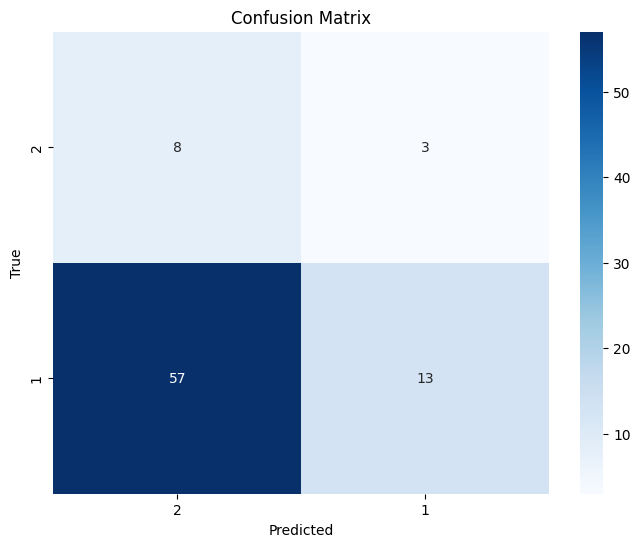

In [65]:

print(classification_report(category_3_data['confidence_2023'], y_test_pred))
cm = confusion_matrix(category_3_data['confidence_2023'], y_test_pred )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [67]:
print(accuracy_score(category_3_data['confidence_2023'], y_test_pred))

0.25925925925925924


Unique classes: [0, 1]
Class 0 AUC: 0.46
Class 1 AUC: 0.46


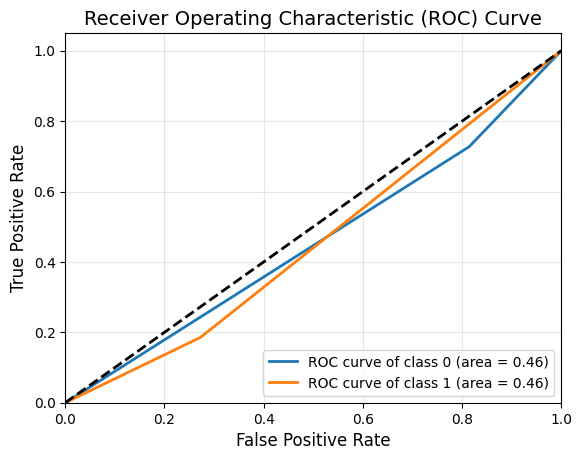

In [68]:
# use the predic function in R on the mars model
predict = ro.r['predict'] # use predict function in R
# use mars to predict
y_pred_response = np.array(predict(mars_model, X_category_3, type="class"))
 
y_prob_split = np.column_stack([1 - y_pred_response, y_pred_response])
unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)

class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}
fpr = {}
tpr = {}
roc_auc = {}
# calculate roc and auc for each category  
for cls in unique_classes:
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(category_3_data['confidence_2023'] == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(f"Class {cls} AUC: {roc_auc[cls]:.2f}")

# roc figure
plt.figure()

for cls in unique_classes:
    plt.plot(fpr[cls], tpr[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})")

 
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [69]:
tn, fp, fn, tp = confusion_matrix(category_3_data['confidence_2023'], y_pred_response).ravel()

# calculate type1 and type 2 error
type_1_error = fp / (fp + tn)  # False Positive Rate
type_2_error = fn / (fn + tp)  # False Negative Rate

print(f"Type I Error (False Positive Rate): {type_1_error:.4f}")
print(f"Type II Error (False Negative Rate): {type_2_error:.4f}")

Type I Error (False Positive Rate): 0.2727
Type II Error (False Negative Rate): 0.8143
